# TinyLlama-1.1B — Fraud Detection

In [1]:
import subprocess, sys

packages = ["transformers", "torch", "accelerate", "codecarbon", "scikit-learn", "matplotlib"]
for pkg in packages:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])

print("All packages installed")

All packages installed


In [2]:
import warnings
warnings.filterwarnings("ignore")

import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    roc_auc_score, f1_score, precision_score,
    recall_score, confusion_matrix, ConfusionMatrixDisplay
)

from codecarbon import EmissionsTracker
import torch
from transformers import AutoTokenizer, pipeline

print(f"Device: {'CUDA (GPU)' if torch.cuda.is_available() else 'CPU'}")
print("All imports successful")

Device: CPU
All imports successful


In [34]:
df = pd.read_csv('creditcard.csv')

# Drop duplicates
df = df.drop_duplicates().reset_index(drop=True)
print(f"Shape: {df.shape}")
print(f"Fraud rate: {df['Class'].mean()*100:.3f}%")

# Scale Amount and Time — V1-V28 are already PCA-scaled
scaler = StandardScaler()
df[['Amount', 'Time']] = scaler.fit_transform(df[['Amount', 'Time']])

df['Class'].value_counts()

Shape: (283726, 31)
Fraud rate: 0.167%


Class
0    283253
1       473
Name: count, dtype: int64

In [4]:
X = df.drop('Class', axis=1)
y = df['Class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {len(X_train):,} rows  |  Test: {len(X_test):,} rows")
print(f"Test fraud count: {y_test.sum()} ({y_test.mean()*100:.3f}%)")

Train: 226,980 rows  |  Test: 56,746 rows
Test fraud count: 95 (0.167%)


In [5]:
# model_id must be defined BEFORE the tokenizer
model_id = "TinyLlama/TinyLlama-1.1B-Chat-v1.0"

print(f"Loading {model_id} ...")
tokenizer = AutoTokenizer.from_pretrained(model_id)

generator = pipeline(
    "text-generation",
    model=model_id,
    device_map="auto",
    torch_dtype=torch.float16 if torch.cuda.is_available() else torch.float32,
)
print(f"Loaded model: {model_id}")

Loading TinyLlama/TinyLlama-1.1B-Chat-v1.0 ...


`torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Some parameters are on the meta device because they were offloaded to the disk.


Loaded model: TinyLlama/TinyLlama-1.1B-Chat-v1.0


In [6]:
def create_tabular_prompt(row):
    """
    Converts a tabular row into a TinyLlama chat prompt.
    Uses V1-V4 + Amount only — keeps prompts short to minimise
    token count and therefore CO2e.
    """
    user_content = (
        f"Analyze this transaction: "
        f"V1={round(row['V1'],3)}, V2={round(row['V2'],3)}, "
        f"V3={round(row['V3'],3)}, V4={round(row['V4'],3)}, "
        f"Amount={round(row['Amount'],2)}. "
        f"Is this fraud? Answer only 'Yes' or 'No'."
    )
    messages = [
        {
            "role": "system",
            "content": "You are a strict fraud detection AI. You must only answer with the exact word 'Yes' (fraud) or 'No' (legitimate). Do not explain your reasoning."
        },
        {"role": "user", "content": user_content}
    ]
    return tokenizer.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=True
    )

In [7]:
# Stratified sample of 300 rows
# ─────────────────────────────────────────────────────────────────────
SAMPLE_SIZE = 300

X_test_r = X_test.reset_index(drop=True)
y_test_r = y_test.reset_index(drop=True)

_, X_samp, _, y_samp = train_test_split(
    X_test_r, y_test_r,
    test_size=SAMPLE_SIZE,
    stratify=y_test_r,
    random_state=42
)
X_samp = X_samp.reset_index(drop=True)
y_samp = y_samp.reset_index(drop=True)

print(f"Sample size : {len(X_samp)}")
print(f"Fraud count : {y_samp.sum()} ({y_samp.mean()*100:.1f}%)")

prompts = X_samp.apply(create_tabular_prompt, axis=1).tolist()

# Preview a sample
print("\nSample Prompt for TinyLlama:")
print(prompts[0])
print(f"\nActual label: {y_samp.iloc[0]} (1=Fraud, 0=Legit)")

Sample size : 300
Fraud count : 1 (0.3%)

Sample Prompt for TinyLlama:
<|system|>
You are a strict fraud detection AI. You must only answer with the exact word 'Yes' (fraud) or 'No' (legitimate). Do not explain your reasoning.</s>
<|user|>
Analyze this transaction: V1=1.282, V2=0.421, V3=0.177, V4=0.599, Amount=-0.35. Is this fraud? Answer only 'Yes' or 'No'.</s>
<|assistant|>


Actual label: 0 (1=Fraud, 0=Legit)


---
## ⚡ Section 5 — Run Inference + Track Carbon

> **Why zero-shot with no fine-tuning?**  
> Fine-tuning TinyLlama would take hours of GPU compute and produce enormous CO₂e — making
> the carbon comparison unfair. Zero-shot is the most generous framing for the LLM:
> training CO₂e = 0 kg. Even so, its inference footprint vs. accuracy makes the
> Responsible AI conclusion clear.

In [8]:

yes_token_id = tokenizer.encode('Yes', add_special_tokens=False)[0]
no_token_id  = tokenizer.encode('No',  add_special_tokens=False)[0]
print(f"'Yes' token id: {yes_token_id}")
print(f"'No'  token id: {no_token_id}")

# Get the underlying model for direct logit access
model = generator.model


def predict_yes_no(prompt: str) -> tuple[int, float]:
    """
    Forced Yes/No prediction via logit comparison.

    Instead of generating free text (where TinyLlama ignores instructions
    and outputs 'Based on...'), we:
      1. Tokenise the prompt
      2. Run one forward pass to get the next-token logits
      3. Compare the logit for 'Yes' vs 'No'
      4. Return whichever is higher — guaranteed Yes or No every time

    Returns (prediction: 0 or 1, yes_probability: float)
    """
    inputs = tokenizer(prompt, return_tensors='pt').to(model.device)
    input_tokens = inputs['input_ids'].shape[1]

    with torch.no_grad():
        outputs = model(**inputs)

    # Logits for the very next token after the prompt
    next_token_logits = outputs.logits[0, -1, :]

    yes_logit = next_token_logits[yes_token_id].item()
    no_logit  = next_token_logits[no_token_id].item()

    # Softmax over just these two tokens for a clean probability
    yes_prob = torch.softmax(
        torch.tensor([yes_logit, no_logit]), dim=0
    )[0].item()

    prediction = 1 if yes_logit > no_logit else 0
    return prediction, yes_prob, input_tokens


# ── Single-sample test ─────────────────────────────────────────────────────
print("Running single-sample test...")
t0 = time.time()
pred, yes_prob, n_tokens = predict_yes_no(prompts[0])
elapsed = time.time() - t0

print("\n--- SINGLE SAMPLE RESULT ---")
print(f"Model Answer   : {'Yes (Fraud)' if pred == 1 else 'No (Legit)'}")
print(f"Yes probability: {yes_prob:.4f}")
print(f"Actual Label   : {y_samp.iloc[0]} (1=Fraud, 0=Legit)")
print(f"Generation Time: {elapsed:.4f}s")
print(f"Input Tokens   : {n_tokens}")
print(f"Output Tokens  : 1  (forced — logit comparison)")
print(f"Total Tokens   : {n_tokens + 1}")

'Yes' token id: 3869
'No'  token id: 1939
Running single-sample test...

--- SINGLE SAMPLE RESULT ---
Model Answer   : Yes (Fraud)
Yes probability: 0.9856
Actual Label   : 0 (1=Fraud, 0=Legit)
Generation Time: 2.6676s
Input Tokens   : 128
Output Tokens  : 1  (forced — logit comparison)
Total Tokens   : 129


In [9]:
print(f"Running TinyLlama zero-shot on {len(prompts)} prompts...")
print("(This may take a few minutes on CPU)\n")

# Start carbon tracker — inference only (training CO2e = 0 for zero-shot)
tracker = EmissionsTracker(
    project_name="TinyLlama_inference",
    output_dir="./carbon_logs",
    log_level="warning",
    save_to_file=True,
)
tracker.start()

llm_preds    = []
yes_probs    = []
total_tokens = 0
total_time   = 0.0

for i, prompt_text in enumerate(prompts):
    t0 = time.time()
    pred, yes_prob, n_tok = predict_yes_no(prompt_text)
    total_time += time.time() - t0

    llm_preds.append(pred)
    yes_probs.append(yes_prob)
    total_tokens += n_tok + 1   # +1 for the single output token

    if (i + 1) % 50 == 0:
        print(f"  {i+1}/{len(prompts)} rows processed...", end="\r")

# Stop tracker
co2_infer_sample = tracker.stop()

# Scale CO2e up to the full test set size
scale_factor     = len(X_test) / len(X_samp)
co2_infer_scaled = round(co2_infer_sample * scale_factor, 8)
co2_train        = 0.0
co2_total        = round(co2_train + co2_infer_scaled, 8)

print(f"\n\nInference complete")
print(f"  Tokens processed (sample)       : {total_tokens:,}")
print(f"  Runtime (sample)                : {total_time:.1f}s")
print(f"  CO2e — sample ({SAMPLE_SIZE} rows)     : {co2_infer_sample:.8f} kg")
print(f"  CO2e — scaled to full test set  : {co2_infer_scaled:.8f} kg")
print(f"  CO2e — training (zero-shot)     : {co2_train:.8f} kg")
print(f"  CO2e — TOTAL                    : {co2_total:.8f} kg")

[codecarbon WARNING @ 13:11:11] Multiple instances of codecarbon are allowed to run at the same time.
[codecarbon WARNING @ 13:11:11] Error while trying to count physical CPUs: [Errno 2] No such file or directory: 'lscpu'. Defaulting to 1.
[codecarbon WARNING @ 13:11:11] We saw that you have a Apple M3 Pro but we don't know it. Please contact us.
[codecarbon WARNING @ 13:11:11] No CPU tracking mode found. Falling back on estimation based on TDP for CPU. 
 Mac OS and ARM processor detected: Please enable PowerMetrics sudo to measure CPU

[codecarbon WARNING @ 13:11:11] No CPU tracking mode found. Falling back on CPU constant mode.


Running TinyLlama zero-shot on 300 prompts...
(This may take a few minutes on CPU)

  250/300 rows processed...

[codecarbon WARNING @ 13:16:16] The CSV format has changed, backing up old emission file.


  300/300 rows processed...

Inference complete
  Tokens processed (sample)       : 38,542
  Runtime (sample)                : 301.3s
  CO2e — sample (300 rows)     : 0.00096444 kg
  CO2e — scaled to full test set  : 0.18242622 kg
  CO2e — training (zero-shot)     : 0.00000000 kg
  CO2e — TOTAL                    : 0.18242622 kg


In [10]:
llm_preds_arr = np.array(llm_preds)
yes_probs_arr = np.array(yes_probs)

# Use yes_probs for AUC — real probabilities from logit comparison
auc       = roc_auc_score(y_samp.values, yes_probs_arr)
f1        = f1_score(y_samp.values, llm_preds_arr, zero_division=0)
precision = precision_score(y_samp.values, llm_preds_arr, zero_division=0)
recall    = recall_score(y_samp.values, llm_preds_arr, zero_division=0)

print("\n" + "=" * 45)
print("  TINYLLAMA-1.1B — RESULTS SUMMARY")
print("=" * 45)
print(f"  AUC                : {auc:.4f}")
print(f"  F1 Score           : {f1:.4f}")
print(f"  Precision          : {precision:.4f}")
print(f"  Recall             : {recall:.4f}")
print("-" * 45)
print(f"  CO2e Training (kg) : {co2_train:.8f}  (zero-shot)")
print(f"  CO2e Inference (kg): {co2_infer_scaled:.8f}  (scaled to full test)")
print(f"  CO2e Total (kg)    : {co2_total:.8f}")
print("=" * 45)
print(f"\nAnswer distribution: {pd.Series(llm_preds).value_counts().to_dict()}")
print("\nShare these numbers with your team for the leaderboard!")


  TINYLLAMA-1.1B — RESULTS SUMMARY
  AUC                : 0.5485
  F1 Score           : 0.0066
  Precision          : 0.0033
  Recall             : 1.0000
---------------------------------------------
  CO2e Training (kg) : 0.00000000  (zero-shot)
  CO2e Inference (kg): 0.18242622  (scaled to full test)
  CO2e Total (kg)    : 0.18242622

Answer distribution: {1: 300}

Share these numbers with your team for the leaderboard!


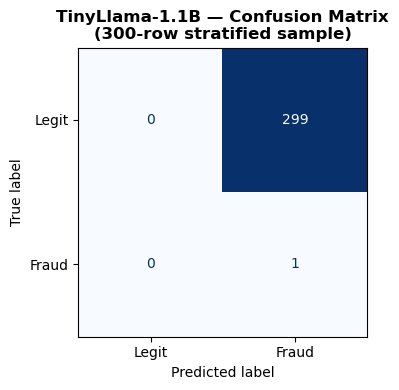

In [11]:
# Confusion Matrix
cm = confusion_matrix(y_samp.values, llm_preds_arr)
fig, ax = plt.subplots(figsize=(5, 4))
disp = ConfusionMatrixDisplay(cm, display_labels=["Legit", "Fraud"])
disp.plot(ax=ax, colorbar=False, cmap="Blues")
ax.set_title("TinyLlama-1.1B — Confusion Matrix\n(300-row stratified sample)",
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig("tinyllama_confusion_matrix.png", dpi=150, bbox_inches='tight')
plt.show()

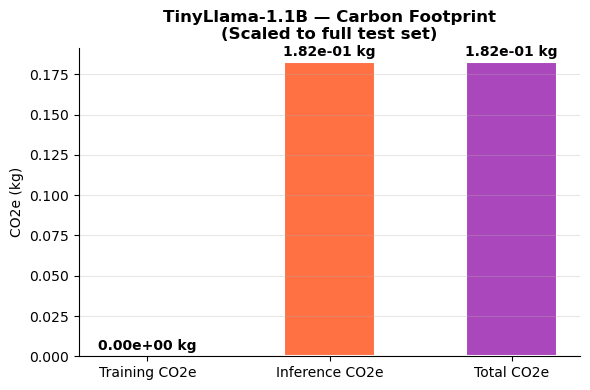

In [12]:
# Carbon Breakdown
fig, ax = plt.subplots(figsize=(6, 4))

categories = ["Training CO2e", "Inference CO2e", "Total CO2e"]
values     = [co2_train, co2_infer_scaled, co2_total]
colours    = ["#42A5F5", "#FF7043", "#AB47BC"]

bars = ax.bar(categories, values, color=colours, edgecolor='white', linewidth=1.5, width=0.5)
for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + max(values) * 0.01,
            f"{val:.2e} kg",
            ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_ylabel("CO2e (kg)")
ax.set_title("TinyLlama-1.1B — Carbon Footprint\n(Scaled to full test set)",
             fontsize=12, fontweight='bold')
ax.grid(axis='y', alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig("tinyllama_carbon.png", dpi=150, bbox_inches='tight')
plt.show()

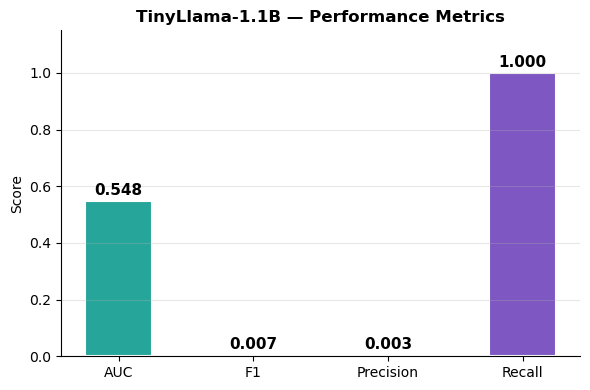

In [13]:
# Performance Metrics
fig, ax = plt.subplots(figsize=(6, 4))

metric_names = ["AUC", "F1", "Precision", "Recall"]
metric_vals  = [auc, f1, precision, recall]
colours_m    = ["#26A69A", "#EC407A", "#FFA726", "#7E57C2"]

bars = ax.bar(metric_names, metric_vals, color=colours_m,
              edgecolor='white', linewidth=1.5, width=0.5)
for bar, val in zip(bars, metric_vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f"{val:.3f}", ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.set_ylim(0, 1.15)
ax.set_ylabel("Score")
ax.set_title("TinyLlama-1.1B — Performance Metrics", fontsize=12, fontweight='bold')
ax.grid(axis='y', alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig("tinyllama_metrics.png", dpi=150, bbox_inches='tight')
plt.show()

---
## 🔧 Section 8 — LoRA Fine-Tuning

We fine-tune TinyLlama using **LoRA (Low-Rank Adaptation)** via the `peft` library.
LoRA freezes the original model weights and inserts small trainable adapter layers,
updating only ~1% of parameters — keeping training CO₂e as low as possible.

### Training setup
- **1,000 rows** — 500 fraud (oversampled) + 500 legit, so the model sees balanced classes
- Each row is formatted as a full chat prompt with the correct Yes/No answer appended
- Carbon is tracked across the entire training run

In [14]:
# Install LoRA / fine-tuning dependencies
subprocess.check_call([sys.executable, "-m", "pip", "install", "-q",
                       "peft", "trl", "datasets"])
print("LoRA packages installed")

LoRA packages installed


In [15]:
from peft import LoraConfig, get_peft_model, TaskType
from trl import SFTTrainer, SFTConfig
from transformers import AutoModelForCausalLM, TrainingArguments
from datasets import Dataset
print("LoRA imports successful")

LoRA imports successful


In [16]:
# ── Build a balanced training set ─────────────────────────────────────────
# The raw dataset is 0.17% fraud — if we train on raw proportions the model
# will just learn to say No every time. We oversample fraud to 50/50.

TRAIN_SIZE = 1000   # total training rows (500 fraud + 500 legit)

train_df = pd.concat([X_train, y_train], axis=1)

fraud_train = train_df[train_df['Class'] == 1]
legit_train = train_df[train_df['Class'] == 0]

# Oversample fraud to 500, undersample legit to 500
from sklearn.utils import resample
fraud_sample = resample(fraud_train, replace=True,  n_samples=TRAIN_SIZE//2, random_state=42)
legit_sample = resample(legit_train, replace=False, n_samples=TRAIN_SIZE//2, random_state=42)

ft_df = pd.concat([fraud_sample, legit_sample]).sample(frac=1, random_state=42).reset_index(drop=True)

print(f"Fine-tune training set: {len(ft_df)} rows")
print(f"Fraud: {ft_df['Class'].sum()}  |  Legit: {(ft_df['Class']==0).sum()}")

Fine-tune training set: 1000 rows
Fraud: 500  |  Legit: 500


In [17]:
# ── Format each row as a complete training prompt ─────────────────────────
# For fine-tuning we append the correct answer so the model learns
# to associate the numeric pattern with the label.

def create_training_prompt(row) -> str:
    user_content = (
        f"Analyze this transaction: "
        f"V1={round(row['V1'],3)}, V2={round(row['V2'],3)}, "
        f"V3={round(row['V3'],3)}, V4={round(row['V4'],3)}, "
        f"Amount={round(row['Amount'],2)}. "
        f"Is this fraud? Answer only 'Yes' or 'No'."
    )
    answer = "Yes" if int(row['Class']) == 1 else "No"

    messages = [
        {
            "role": "system",
            "content": "You are a strict fraud detection AI. You must only answer with the exact word 'Yes' (fraud) or 'No' (legitimate). Do not explain your reasoning."
        },
        {"role": "user",      "content": user_content},
        {"role": "assistant", "content": answer},
    ]
    # tokenize=False gives us the full string including the answer
    return tokenizer.apply_chat_template(messages, tokenize=False)


ft_df['text'] = ft_df.apply(create_training_prompt, axis=1)

# Convert to HuggingFace Dataset
hf_dataset = Dataset.from_pandas(ft_df[['text']])

print(f"Dataset ready: {len(hf_dataset)} rows")
print("\nSample training prompt:")
print(ft_df['text'].iloc[0])

Dataset ready: 1000 rows

Sample training prompt:
<|system|>
You are a strict fraud detection AI. You must only answer with the exact word 'Yes' (fraud) or 'No' (legitimate). Do not explain your reasoning.</s>
<|user|>
Analyze this transaction: V1=-0.868, V2=0.933, V3=0.572, V4=-0.107, Amount=-0.27. Is this fraud? Answer only 'Yes' or 'No'.</s>
<|assistant|>
No</s>



In [25]:
from peft import LoraConfig, get_peft_model, TaskType
from trl import SFTTrainer, SFTConfig
from transformers import AutoModelForCausalLM

device = torch.device('cpu')
print(f"Training on: {device}")

ft_model = AutoModelForCausalLM.from_pretrained(
    model_id,
    torch_dtype=torch.float32,  
    device_map=None,            
)
ft_model = ft_model.to(device)

lora_config = LoraConfig(
    task_type=TaskType.CAUSAL_LM,
    r=8,
    lora_alpha=16,
    lora_dropout=0.05,
    target_modules=["q_proj", "v_proj"],
    bias="none",
)
ft_model = get_peft_model(ft_model, lora_config)
ft_model.print_trainable_parameters()

# Carbon tracking
tracker_ft = EmissionsTracker(
    project_name="TinyLlama_LoRA_training",
    output_dir="./carbon_logs",
    log_level="warning",
    save_to_file=True,
)
tracker_ft.start()

training_args = SFTConfig(
    output_dir="./tinyllama_lora",
    num_train_epochs=3,
    per_device_train_batch_size=4,
    gradient_accumulation_steps=4,
    learning_rate=2e-4,
    warmup_steps=20,
    logging_steps=10,
    save_strategy="no",
    fp16=False,                 
    report_to="none",
    max_length=256,
    dataset_text_field="text",
)

trainer = SFTTrainer(
    model=ft_model,
    train_dataset=hf_dataset,
    args=training_args,
)

trainer.train()

co2_ft_train = tracker_ft.stop()
co2_ft_train = round(co2_ft_train, 8)
print(f"\nFine-tuning complete")
print(f"  Training CO2e : {co2_ft_train:.8f} kg")

Training on: cpu


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

[codecarbon WARNING @ 13:26:33] Multiple instances of codecarbon are allowed to run at the same time.
[codecarbon WARNING @ 13:26:33] Error while trying to count physical CPUs: [Errno 2] No such file or directory: 'lscpu'. Defaulting to 1.


trainable params: 1,126,400 || all params: 1,101,174,784 || trainable%: 0.1023


[codecarbon WARNING @ 13:26:33] We saw that you have a Apple M3 Pro but we don't know it. Please contact us.
[codecarbon WARNING @ 13:26:33] No CPU tracking mode found. Falling back on estimation based on TDP for CPU. 
 Mac OS and ARM processor detected: Please enable PowerMetrics sudo to measure CPU

[codecarbon WARNING @ 13:26:33] No CPU tracking mode found. Falling back on CPU constant mode.


...

Tokenizing train dataset:   0%|          | 0/1000 [00:00<?, ? examples/s]

Truncating train dataset:   0%|          | 0/1000 [00:00<?, ? examples/s]

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'pad_token_id': 2}.


Step,Training Loss
10,2.794015
20,2.353614
30,1.406006
40,0.686835
50,0.398098
60,0.360192
70,0.342557
80,0.335004
90,0.328754
100,0.327368



Fine-tuning complete
  Training CO2e : 0.00293902 kg


In [26]:
# ── Run inference with fine-tuned model ───────────────────────────────────

def predict_yes_no_ft(prompt: str) -> tuple:
    """Same logit-based forced Yes/No — using the fine-tuned model."""
    inputs = tokenizer(prompt, return_tensors='pt').to(ft_model.device)
    n_tok  = inputs['input_ids'].shape[1]

    with torch.no_grad():
        outputs = ft_model(**inputs)

    logits   = outputs.logits[0, -1, :]
    yes_prob = torch.softmax(
        torch.tensor([logits[yes_token_id].item(), logits[no_token_id].item()]), dim=0
    )[0].item()
    pred = 1 if logits[yes_token_id] > logits[no_token_id] else 0
    return pred, yes_prob, n_tok


print(f"Running fine-tuned TinyLlama on {len(prompts)} prompts...")

tracker_ft_infer = EmissionsTracker(
    project_name="TinyLlama_LoRA_inference",
    output_dir="./carbon_logs",
    log_level="warning",
    save_to_file=True,
)
tracker_ft_infer.start()

ft_preds      = []
ft_yes_probs  = []
ft_tokens     = 0
ft_time       = 0.0

for i, prompt_text in enumerate(prompts):
    t0 = time.time()
    pred, yp, ntok = predict_yes_no_ft(prompt_text)
    ft_time += time.time() - t0

    ft_preds.append(pred)
    ft_yes_probs.append(yp)
    ft_tokens += ntok + 1

    if (i + 1) % 50 == 0:
        print(f"  {i+1}/{len(prompts)} rows processed...", end="\r")

co2_ft_infer_sample = tracker_ft_infer.stop()
co2_ft_infer_scaled = round(co2_ft_infer_sample * scale_factor, 8)
co2_ft_total        = round(co2_ft_train + co2_ft_infer_scaled, 8)

print(f"\n\nFine-tuned inference complete")
print(f"  CO2e Training  : {co2_ft_train:.8f} kg")
print(f"  CO2e Inference : {co2_ft_infer_scaled:.8f} kg  (scaled to full test)")
print(f"  CO2e TOTAL     : {co2_ft_total:.8f} kg")

[codecarbon WARNING @ 13:41:54] Multiple instances of codecarbon are allowed to run at the same time.
[codecarbon WARNING @ 13:41:54] Error while trying to count physical CPUs: [Errno 2] No such file or directory: 'lscpu'. Defaulting to 1.
[codecarbon WARNING @ 13:41:54] We saw that you have a Apple M3 Pro but we don't know it. Please contact us.
[codecarbon WARNING @ 13:41:54] No CPU tracking mode found. Falling back on estimation based on TDP for CPU. 
 Mac OS and ARM processor detected: Please enable PowerMetrics sudo to measure CPU

[codecarbon WARNING @ 13:41:54] No CPU tracking mode found. Falling back on CPU constant mode.


Running fine-tuned TinyLlama on 300 prompts...
  300/300 rows processed...

Fine-tuned inference complete
  CO2e Training  : 0.00293902 kg
  CO2e Inference : 0.02742651 kg  (scaled to full test)
  CO2e TOTAL     : 0.03036553 kg


In [27]:
# ── Evaluate fine-tuned model ──────────────────────────────────────────────
ft_preds_arr     = np.array(ft_preds)
ft_yes_probs_arr = np.array(ft_yes_probs)

ft_auc       = roc_auc_score(y_samp.values, ft_yes_probs_arr)
ft_f1        = f1_score(y_samp.values, ft_preds_arr, zero_division=0)
ft_precision = precision_score(y_samp.values, ft_preds_arr, zero_division=0)
ft_recall    = recall_score(y_samp.values, ft_preds_arr, zero_division=0)

print("\n" + "=" * 50)
print("  BEFORE vs AFTER FINE-TUNING")
print("=" * 50)
print(f"{'Metric':<18} {'Zero-Shot':>12} {'Fine-Tuned':>12}  {'Change':>10}")
print("-" * 50)
for metric, before, after in [
    ("AUC",       auc,       ft_auc),
    ("F1",        f1,        ft_f1),
    ("Precision", precision, ft_precision),
    ("Recall",    recall,    ft_recall),
]:
    delta = after - before
    sign  = "+" if delta >= 0 else ""
    print(f"  {metric:<16} {before:>12.4f} {after:>12.4f}  {sign}{delta:>9.4f}")
print("-" * 50)
for metric, before, after in [
    ("CO2e Train (kg)",  co2_train,        co2_ft_train),
    ("CO2e Infer (kg)",  co2_infer_scaled, co2_ft_infer_scaled),
    ("CO2e Total (kg)",  co2_total,        co2_ft_total),
]:
    delta = after - before
    sign  = "+" if delta >= 0 else ""
    print(f"  {metric:<16} {before:>12.8f} {after:>12.8f}  {sign}{delta:>9.8f}")
print("=" * 50)
print(f"\nAnswer distribution (fine-tuned): {pd.Series(ft_preds).value_counts().to_dict()}")


  BEFORE vs AFTER FINE-TUNING
Metric                Zero-Shot   Fine-Tuned      Change
--------------------------------------------------
  AUC                    0.5485       0.5970  +   0.0485
  F1                     0.0066       0.0066  +   0.0000
  Precision              0.0033       0.0033  +   0.0000
  Recall                 1.0000       1.0000  +   0.0000
--------------------------------------------------
  CO2e Train (kg)    0.00000000   0.00293902  +0.00293902
  CO2e Infer (kg)    0.18242622   0.02742651  -0.15499971
  CO2e Total (kg)    0.18242622   0.03036553  -0.15206069

Answer distribution (fine-tuned): {1: 300}


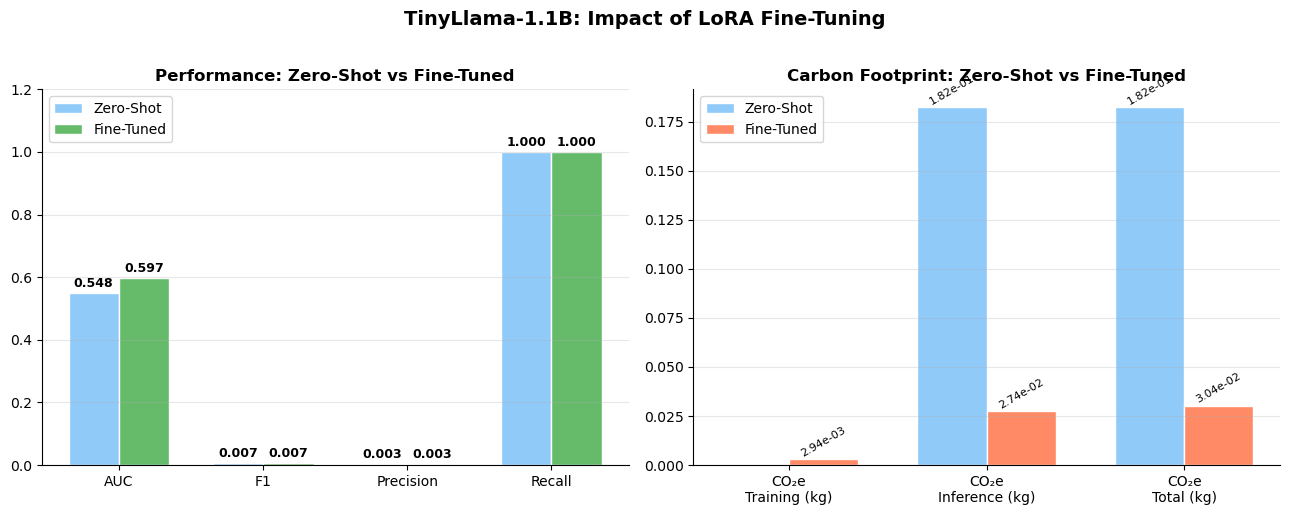

In [28]:
# ── Before vs After visualisation ─────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ── Left: Performance metrics comparison ──
ax = axes[0]
metric_labels = ["AUC", "F1", "Precision", "Recall"]
zs_vals = [auc, f1, precision, recall]
ft_vals = [ft_auc, ft_f1, ft_precision, ft_recall]

x = np.arange(len(metric_labels))
w = 0.35
b1 = ax.bar(x - w/2, zs_vals, w, label="Zero-Shot",   color="#90CAF9", edgecolor='white')
b2 = ax.bar(x + w/2, ft_vals, w, label="Fine-Tuned",  color="#66BB6A", edgecolor='white')

for bar, val in [(b, v) for bars, vals in [(b1, zs_vals), (b2, ft_vals)]
                 for b, v in zip(bars, vals)]:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f"{val:.3f}", ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(metric_labels)
ax.set_ylim(0, 1.2)
ax.set_title("Performance: Zero-Shot vs Fine-Tuned", fontsize=12, fontweight='bold')
ax.legend()
ax.grid(axis='y', alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# ── Right: CO2e comparison ──
ax = axes[1]
co2_labels  = ["Training", "Inference", "Total"]
co2_zs_vals = [co2_train,     co2_infer_scaled, co2_total]
co2_ft_vals = [co2_ft_train,  co2_ft_infer_scaled, co2_ft_total]

x2 = np.arange(len(co2_labels))
c1 = ax.bar(x2 - w/2, co2_zs_vals, w, label="Zero-Shot",  color="#90CAF9", edgecolor='white')
c2 = ax.bar(x2 + w/2, co2_ft_vals, w, label="Fine-Tuned", color="#FF8A65", edgecolor='white')

for bar, val in [(b, v) for bars, vals in [(c1, co2_zs_vals), (c2, co2_ft_vals)]
                 for b, v in zip(bars, vals)]:
    if val > 0:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(co2_ft_vals)*0.01,
                f"{val:.2e}", ha='center', va='bottom', fontsize=8, rotation=30)

ax.set_xticks(x2)
ax.set_xticklabels([f"CO₂e\n{l} (kg)" for l in co2_labels])
ax.set_title("Carbon Footprint: Zero-Shot vs Fine-Tuned", fontsize=12, fontweight='bold')
ax.legend()
ax.grid(axis='y', alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.suptitle("TinyLlama-1.1B: Impact of LoRA Fine-Tuning",
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig("tinyllama_finetune_comparison.png", dpi=150, bbox_inches='tight')
plt.show()

In [29]:
# Two rows — zero-shot and fine-tuned — for the team leaderboard
tinyllama_results = pd.DataFrame([
    {
        "Model":           "TinyLlama-1.1B (zero-shot)",
        "AUC":             round(auc, 4),
        "F1":              round(f1, 4),
        "Precision":       round(precision, 4),
        "Recall":          round(recall, 4),
        "CO2e_train_kg":   co2_train,
        "CO2e_infer_kg":   co2_infer_scaled,
        "CO2e_total_kg":   co2_total,
        "Sample_size":     SAMPLE_SIZE,
        "Scale_factor":    round(scale_factor, 2),
        "Total_tokens":    total_tokens,
        "Runtime_secs":    round(total_time, 2),
    },
    {
        "Model":           "TinyLlama-1.1B (LoRA fine-tuned)",
        "AUC":             round(ft_auc, 4),
        "F1":              round(ft_f1, 4),
        "Precision":       round(ft_precision, 4),
        "Recall":          round(ft_recall, 4),
        "CO2e_train_kg":   co2_ft_train,
        "CO2e_infer_kg":   co2_ft_infer_scaled,
        "CO2e_total_kg":   co2_ft_total,
        "Sample_size":     SAMPLE_SIZE,
        "Scale_factor":    round(scale_factor, 2),
        "Total_tokens":    ft_tokens,
        "Runtime_secs":    round(ft_time, 2),
    }
])

tinyllama_results.to_csv("tinyllama_results.csv", index=False)

print("Results saved to tinyllama_results.csv")
print(tinyllama_results.T.to_string())

Results saved to tinyllama_results.csv

Share these rows with your team:
                                        0                                 1
Model          TinyLlama-1.1B (zero-shot)  TinyLlama-1.1B (LoRA fine-tuned)
AUC                                0.5485                             0.597
F1                                 0.0066                            0.0066
Precision                          0.0033                            0.0033
Recall                                1.0                               1.0
CO2e_train_kg                         0.0                          0.002939
CO2e_infer_kg                    0.182426                          0.027427
CO2e_total_kg                    0.182426                          0.030366
Sample_size                           300                               300
Scale_factor                       189.15                            189.15
Total_tokens                        38542                             38542
Runtime_secs   